# FEATURE ENGINEERING V1 + Chronos
Pipeline:

`nba_full_dataset.csv` -> Fix issues -> Chronos Forecast (PTS, FG_PCT) + EMA Rolling (others) -> Ghép 2 đội -> Difference Features -> Train/Test Split -> **Model-ready dataset**

# 0. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import json
import warnings
import torch
warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/datasets/nguyenbb/nbaaaa/nba_full_dataset.csv')
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

print(f'Dataset gốc: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Số trận: {df["GAME_ID"].nunique()}')
print(f'Mùa giải: {sorted(df["SEASON"].unique())}')
print(f'\nCác cột hiện có:')
print(list(df.columns))

Dataset gốc: 12156 dòng × 36 cột
Số trận: 6078
Mùa giải: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']

Các cột hiện có:
['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS', 'SEASON', 'IS_HOME', 'WIN', 'REST_DAYS', 'IS_B2B', 'GAMES_PLAYED_SEASON', 'CURRENT_WIN_PCT', 'WIN_STREAK']


# 1. Xử lý vấn đề phát hiện từ EDA

- `FT_PCT` có 1 missing value -> fill 0
- `REST_DAYS` có thể có outlier -> cap ở 10 ngày
- Trận neutral site -> Cả 2 đội đều IS_HOME = 0 -> loại

In [2]:
# 1.1 - Fill missing
df['FT_PCT'] = df['FT_PCT'].fillna(0)

# 1.2 - Cap REST_DAYS
print(f'REST_DAYS trước khi cap: min={df["REST_DAYS"].min()}, max={df["REST_DAYS"].max()}')
df['REST_DAYS'] = df['REST_DAYS'].clip(upper=10)
print(f'REST_DAYS sau khi cap:   min={df["REST_DAYS"].min()}, max={df["REST_DAYS"].max()}')

# 1.3 — Loại trận neutral site (cả 2 đội IS_HOME=0)
game_home_count = df.groupby('GAME_ID')['IS_HOME'].sum()
neutral_games = game_home_count[game_home_count != 1].index
n_neutral = len(neutral_games)
df = df[~df['GAME_ID'].isin(neutral_games)]

print(f'\nLoại {n_neutral} trận neutral site (cả 2 đội IS_HOME=0)')
print(f'Dataset sau xử lý: {df.shape[0]} dòng, {df["GAME_ID"].nunique()} trận')

# Xác nhận: mỗi trận có đúng 1 HOME + 1 AWAY
home_count = (df['IS_HOME'] == 1).sum()
away_count = (df['IS_HOME'] == 0).sum()
print(f'HOME: {home_count}, AWAY: {away_count}')

REST_DAYS trước khi cap: min=1.0, max=9.0
REST_DAYS sau khi cap:   min=1.0, max=9.0

Loại 10 trận neutral site (cả 2 đội IS_HOME=0)
Dataset sau xử lý: 12136 dòng, 6068 trận
HOME: 6068, AWAY: 6068


## 2. Chronos Forecast (PTS, FG_PCT) + EMA Rolling (các chỉ số còn lại)

### Ý tưởng chính
- Đưa lịch sử điểm số (PTS) và tỷ lệ ném (FG_PCT) từng đội vào Chronos để dự báo trận kế tiếp
- Thay thế EMA_PTS, EMA_FG_PCT bằng CHRONOS_PREDICTED_PTS, CHRONOS_PREDICTED_FG_PCT

### Các chỉ số còn lại vẫn dùng EMA
- FG3_PCT, FT_PCT, OREB, DREB, AST, STL, BLK, TOV

### Tránh Data Leakage
- Chronos chỉ dùng lịch sử trước trận hiện tại
- EMA vẫn dùng `shift(1)` như bản gốc

In [3]:
CHRONOS_FEATURES = ['PTS', 'FG_PCT']
EMA_FEATURES = ['FG3_PCT', 'FT_PCT', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV']
EMA_SPAN = 5
CHRONOS_MODEL = 'amazon/chronos-t5-small'

print(f'Chronos features: {CHRONOS_FEATURES}')
print(f'EMA features: {EMA_FEATURES}')
print(f'EMA span: {EMA_SPAN} trận')
print(f'Chronos model: {CHRONOS_MODEL}')

Chronos features: ['PTS', 'FG_PCT']
EMA features: ['FG3_PCT', 'FT_PCT', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV']
EMA span: 5 trận
Chronos model: amazon/chronos-t5-small


In [4]:
pip install chronos-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 104.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
import numpy as np
import pandas as pd

# Sắp xếp theo đội + mùa + thời gian
df = df.sort_values(['TEAM_ID', 'SEASON', 'GAME_DATE']).reset_index(drop=True)

# Chronos pipeline
try:
    from chronos import ChronosPipeline
except ImportError as exc:
    raise ImportError('Missing Chronos. Install with: pip install chronos-forecasting') from exc

pipeline = ChronosPipeline.from_pretrained(
    CHRONOS_MODEL,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

# Tối ưu 1: Viết lại hàm dự đoán để nhận một list các tensors (Batch Inference)
def chronos_predict_batch(context_list):
    if not context_list:
        return []
    
    # Tối ưu 2: Dùng inference_mode để tắt tính toán gradient, giúp chạy nhanh và ít tốn VRAM hơn
    with torch.inference_mode():
        forecast = pipeline.predict(
            context_list, 
            prediction_length=1
        )
    
    forecast_np = forecast.numpy()
    # Lấy median của tất cả các samples cho toàn bộ batch cùng lúc
    median_preds = np.median(forecast_np[:, :, 0], axis=1)
    return median_preds.tolist()

# Dự báo 1 bước cho từng đội + mùa
for feat in CHRONOS_FEATURES:
    df[f'CHRONOS_PREDICTED_{feat}'] = np.nan

for (team_id, season), g in df.groupby(['TEAM_ID', 'SEASON'], sort=False):
    idx = g.index
    for feat in CHRONOS_FEATURES:
        series = g[feat].to_numpy(dtype='float32')
        preds = [np.nan] * len(series)
        
        contexts = []
        valid_indices = []
        
        for i in range(1, len(series)):
            # Tối ưu 3: Chỉ lấy tối đa 20 trận gần nhất để làm context, giảm tải sequence length
            history = series[max(0, i-20):i]
            contexts.append(torch.tensor(history, dtype=torch.float32))
            valid_indices.append(i)
            
        # Gửi toàn bộ batch vào dự báo 1 lần
        if contexts:
            batch_preds = chronos_predict_batch(contexts)
            for i, pred in zip(valid_indices, batch_preds):
                preds[i] = float(pred)
                
        if feat == 'FG_PCT':
            preds = [np.nan if pd.isna(p) else float(np.clip(p, 0.0, 1.0)) for p in preds]
            
        df.loc[idx, f'CHRONOS_PREDICTED_{feat}'] = preds

# Tính EMA cho các feature còn lại
for feat in EMA_FEATURES:
    col_name = f'EMA_{feat}'
    shifted = df.groupby(['TEAM_ID', 'SEASON'])[feat].shift(1)
    df[col_name] = shifted.groupby([df['TEAM_ID'], df['SEASON']]).transform(
        lambda x: x.ewm(span=EMA_SPAN, adjust=False).mean()
    )

print(f'Số cột mới: {len(CHRONOS_FEATURES)} Chronos + {len(EMA_FEATURES)} EMA')

2026-04-28 18:06:29.336505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777399589.595482      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777399589.660666      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777399590.208070      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777399590.208109      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777399590.208111      55 computation_placer.cc:177] computation placer alr

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Số cột mới: 2 Chronos + 8 EMA


In [6]:
# Kiểm tra: 8 trận đầu của 1 đội
sample_team = df['TEAM_ABBREVIATION'].iloc[0]
sample_season = df['SEASON'].iloc[0]
sample_mask = (df['TEAM_ABBREVIATION'] == sample_team) & (df['SEASON'] == sample_season)

print(f'Ví dụ: 8 trận đầu của {sample_team} mùa {sample_season}')
print('-' * 110)
check_cols = [
    'GAME_DATE',
    'PTS', 'CHRONOS_PREDICTED_PTS',
    'FG_PCT', 'CHRONOS_PREDICTED_FG_PCT',
    'AST', 'EMA_AST',
 ]
print(df[sample_mask].head(8)[check_cols].to_string(index=False))

print(f'\n→ Trận 1: NaN (chưa có lịch sử — sẽ bị loại khi ghép đội)')
print(f'→ Trận 2: Chronos dự báo từ 1 điểm dữ liệu trước đó')
print(f'→ Trận 3+: Chronos có nhiều lịch sử hơn, EMA bắt đầu smooth')

Ví dụ: 8 trận đầu của ATL mùa 2021-22
--------------------------------------------------------------------------------------------------------------
 GAME_DATE  PTS  CHRONOS_PREDICTED_PTS  FG_PCT  CHRONOS_PREDICTED_FG_PCT  AST   EMA_AST
2021-10-21  113                    NaN   0.479                       NaN   31       NaN
2021-10-23   95             112.668625   0.384                  0.475839   20 31.000000
2021-10-25  122              95.689148   0.511                  0.384364   24 27.333333
2021-10-27  102             115.725815   0.417                  0.505345   21 26.222222
2021-10-28  111              99.369507   0.545                  0.459567   26 24.481481
2021-10-30   94             108.679619   0.379                  0.489806   24 24.987654
2021-11-01  118              93.790932   0.458                  0.421316   24 24.658436
2021-11-03  108             103.191772   0.436                  0.443648   23 24.438957

→ Trận 1: NaN (chưa có lịch sử — sẽ bị loại khi ghép đội)


# 3. Ghép 2 đội thành 1 dòng

In [7]:
# Định nghĩa các features của mỗi đội sẽ đưa vào model
team_features = (
    [f'CHRONOS_PREDICTED_{f}' for f in CHRONOS_FEATURES]  # 2 Chronos features
    + [f'EMA_{f}' for f in EMA_FEATURES]  # 8 EMA features
    + ['CURRENT_WIN_PCT', 'WIN_STREAK', 'REST_DAYS', 'IS_B2B']  # 4 contextual
 )

print(f'Features mỗi đội: {len(team_features)} cột')
for f in team_features:
    print(f'  - {f}')

Features mỗi đội: 14 cột
  - CHRONOS_PREDICTED_PTS
  - CHRONOS_PREDICTED_FG_PCT
  - EMA_FG3_PCT
  - EMA_FT_PCT
  - EMA_OREB
  - EMA_DREB
  - EMA_AST
  - EMA_STL
  - EMA_BLK
  - EMA_TOV
  - CURRENT_WIN_PCT
  - WIN_STREAK
  - REST_DAYS
  - IS_B2B


In [8]:
# Tách HOME và AWAY
home_df = df[df['IS_HOME'] == 1].copy()
away_df = df[df['IS_HOME'] == 0].copy()

# Các cột chung (metadata)
game_cols = ['GAME_ID', 'GAME_DATE', 'SEASON']

# Rename: thêm prefix HOME_ / AWAY_
home_rename = {f: f'HOME_{f}' for f in team_features}
home_rename['TEAM_ABBREVIATION'] = 'HOME_TEAM'
home_rename['WIN'] = 'HOME_WIN'

away_rename = {f: f'AWAY_{f}' for f in team_features}
away_rename['TEAM_ABBREVIATION'] = 'AWAY_TEAM'

home_df = home_df.rename(columns=home_rename)
away_df = away_df.rename(columns=away_rename)

# Chọn cột cần giữ
home_cols = game_cols + ['HOME_TEAM', 'HOME_WIN'] + [f'HOME_{f}' for f in team_features]
away_cols = ['GAME_ID', 'AWAY_TEAM'] + [f'AWAY_{f}' for f in team_features]

# Merge theo GAME_ID
merged = home_df[home_cols].merge(away_df[away_cols], on='GAME_ID', how='inner')

# Loại NaN (trận đầu mùa không có EMA)
before = len(merged)
merged = merged.dropna().reset_index(drop=True)
print(f'Sau ghép: {before} trận → loại {before - len(merged)} NaN → còn {len(merged)} trận')
print(f'Shape: {merged.shape}')

Sau ghép: 6068 trận → loại 79 NaN → còn 5989 trận
Shape: (5989, 34)


In [9]:
# Kiểm tra
print('Ví dụ 3 trận đầu:')
print('=' * 90)
for idx, row in merged.head(3).iterrows():
    print(f'\n{row["HOME_TEAM"]} (nhà) vs {row["AWAY_TEAM"]} (khách) | {row["GAME_DATE"]}')
    print(f'  HOME: CHRONOS_PTS={row["HOME_CHRONOS_PREDICTED_PTS"]:.1f}, WIN_PCT={row["HOME_CURRENT_WIN_PCT"]:.3f}')
    print(f'  AWAY: CHRONOS_PTS={row["AWAY_CHRONOS_PREDICTED_PTS"]:.1f}, WIN_PCT={row["AWAY_CURRENT_WIN_PCT"]:.3f}')
    print(f'  → {"HOME thắng" if row["HOME_WIN"]==1 else "AWAY thắng"}')

print(f'\nLabel: HOME thắng {merged["HOME_WIN"].mean():.1%}, AWAY thắng {(1-merged["HOME_WIN"]).mean():.1%}')

Ví dụ 3 trận đầu:

ATL (nhà) vs DET (khách) | 2021-10-25 00:00:00
  HOME: CHRONOS_PTS=95.7, WIN_PCT=0.500
  AWAY: CHRONOS_PTS=84.8, WIN_PCT=0.000
  → HOME thắng

ATL (nhà) vs WAS (khách) | 2021-11-01 00:00:00
  HOME: CHRONOS_PTS=93.8, WIN_PCT=0.500
  AWAY: CHRONOS_PTS=116.5, WIN_PCT=0.833
  → HOME thắng

ATL (nhà) vs UTA (khách) | 2021-11-04 00:00:00
  HOME: CHRONOS_PTS=113.9, WIN_PCT=0.500
  AWAY: CHRONOS_PTS=114.8, WIN_PCT=0.857
  → AWAY thắng

Label: HOME thắng 55.2%, AWAY thắng 44.8%


# 4. Difference Features (HOME - AWAY)

- **Horvat (2023)**: chỉ số ICMPR (hiệu giữa 2 đội) giúp accuracy tăng từ 55.8% → 64.5%
- **Migliorati (2022)**: diff index là yếu tố phân biệt quan trọng nhất

In [10]:
DIFF_FEATURES = {
    # 2 Chronos features
    'CHRONOS_PREDICTED_PTS': 'DIFF_PTS',
    'CHRONOS_PREDICTED_FG_PCT': 'DIFF_FG_PCT',
    # 8 EMA features
    'EMA_FG3_PCT': 'DIFF_FG3_PCT',
    'EMA_FT_PCT': 'DIFF_FT_PCT',
    'EMA_OREB': 'DIFF_OREB',
    'EMA_DREB': 'DIFF_DREB',
    'EMA_AST': 'DIFF_AST',
    'EMA_STL': 'DIFF_STL',
    'EMA_BLK': 'DIFF_BLK',
    'EMA_TOV': 'DIFF_TOV',
    # 3 contextual features
    'CURRENT_WIN_PCT': 'DIFF_WIN_PCT',
    'WIN_STREAK': 'DIFF_WIN_STREAK',
    'REST_DAYS': 'DIFF_REST_DAYS',
}

In [11]:
for feat, diff_name in DIFF_FEATURES.items():
    merged[diff_name] = merged[f'HOME_{feat}'] - merged[f'AWAY_{feat}']

print(f'Đã tạo {len(DIFF_FEATURES)} difference features:')
print('-' * 60)
for diff_name in DIFF_FEATURES.values():
    val = merged[diff_name]
    print(f'  {diff_name:20s}: mean={val.mean():+.4f}, std={val.std():.4f}')

Đã tạo 13 difference features:
------------------------------------------------------------
  DIFF_PTS            : mean=-0.2378, std=12.0455
  DIFF_FG_PCT         : mean=+0.0001, std=0.0520
  DIFF_FG3_PCT        : mean=-0.0014, std=0.0566
  DIFF_FT_PCT         : mean=-0.0006, std=0.0735
  DIFF_OREB           : mean=+0.0135, std=3.1388
  DIFF_DREB           : mean=+0.0152, std=4.0665
  DIFF_AST            : mean=-0.0661, std=4.1238
  DIFF_STL            : mean=-0.0181, std=2.2084
  DIFF_BLK            : mean=-0.0100, std=1.8912
  DIFF_TOV            : mean=+0.0078, std=2.8227
  DIFF_WIN_PCT        : mean=-0.0030, std=0.2613
  DIFF_WIN_STREAK     : mean=+0.0524, std=4.7492
  DIFF_REST_DAYS      : mean=+0.0825, std=1.0031


# 5. Định nghĩa bộ Features cho Model

In [12]:
# Bộ features cho model
feature_set = list(DIFF_FEATURES.values()) + ['HOME_IS_B2B', 'AWAY_IS_B2B']

LABEL = 'HOME_WIN'

print(f'Bộ features: {len(feature_set)} cột')
print(f'Label: {LABEL}')
print(f'\nDanh sách features:')
for i, f in enumerate(feature_set, 1):
    print(f'  {i:2d}. {f}')

Bộ features: 15 cột
Label: HOME_WIN

Danh sách features:
   1. DIFF_PTS
   2. DIFF_FG_PCT
   3. DIFF_FG3_PCT
   4. DIFF_FT_PCT
   5. DIFF_OREB
   6. DIFF_DREB
   7. DIFF_AST
   8. DIFF_STL
   9. DIFF_BLK
  10. DIFF_TOV
  11. DIFF_WIN_PCT
  12. DIFF_WIN_STREAK
  13. DIFF_REST_DAYS
  14. HOME_IS_B2B
  15. AWAY_IS_B2B


# 6. Train / Test split (2 lần chia)

In [13]:
# =============================================
# LẦN 1: Đánh giá (báo cáo)
# =============================================
eval_train_seasons = ['2021-22', '2022-23', '2023-24', '2024-25']
eval_test_season = '2025-26'

eval_train = merged[merged['SEASON'].isin(eval_train_seasons)].copy()
eval_test = merged[merged['SEASON'] == eval_test_season].copy()

print('LẦN 1 — ĐÁNH GIÁ MODEL (BÁO CÁO)')
print('=' * 50)
print(f'Train: {len(eval_train)} trận | {eval_train["GAME_DATE"].min().date()} → {eval_train["GAME_DATE"].max().date()}')
print(f'Test:  {len(eval_test)} trận | {eval_test["GAME_DATE"].min().date()} → {eval_test["GAME_DATE"].max().date()}')


print(f'Train HOME_WIN: {eval_train["HOME_WIN"].mean():.1%} | Test HOME_WIN: {eval_test["HOME_WIN"].mean():.1%}')

LẦN 1 — ĐÁNH GIÁ MODEL (BÁO CÁO)
Train: 4852 trận | 2021-10-22 → 2025-04-13
Test:  1137 trận | 2025-10-24 → 2026-04-03
Train HOME_WIN: 55.4% | Test HOME_WIN: 54.7%


In [14]:
# =============================================
# LẦN 2: Model cuối cùng (demo)
# =============================================
final_train = merged.copy()

print('\nLẦN 2 — MODEL CUỐI CÙNG (DEMO)')
print('=' * 50)
print(f'Train: {len(final_train)} trận (TẤT CẢ dữ liệu)')
print(f'Train: {final_train["GAME_DATE"].min().date()} → {final_train["GAME_DATE"].max().date()}')
print(f'→ Predict: các trận SAU {final_train["GAME_DATE"].max().date()}')


LẦN 2 — MODEL CUỐI CÙNG (DEMO)
Train: 5989 trận (TẤT CẢ dữ liệu)
Train: 2021-10-22 → 2026-04-03
→ Predict: các trận SAU 2026-04-03


In [15]:
# Tách X, y
# Lần 1
X_eval_train = eval_train[feature_set]
X_eval_test  = eval_test[feature_set]
y_eval_train = eval_train[LABEL]
y_eval_test  = eval_test[LABEL]

# Lần 2
X_final = final_train[feature_set]
y_final = final_train[LABEL]

print('LẦN 1:')
print(f'  train: X={X_eval_train.shape}, y={y_eval_train.shape}')
print(f'  test:  X={X_eval_test.shape}, y={y_eval_test.shape}')
print(f'\nLẦN 2:')
print(f'  train: X={X_final.shape}, y={y_final.shape}')

LẦN 1:
  train: X=(4852, 15), y=(4852,)
  test:  X=(1137, 15), y=(1137,)

LẦN 2:
  train: X=(5989, 15), y=(5989,)


1. ĐANG LOAD DỮ LIỆU...
✅ X_train shape: (4852, 15) | y_train phân bố: 55.4% Home Win
✅ X_test shape:  (1137, 15)  | y_test phân bố:  54.7% Home Win

2. ĐANG HUẤN LUYỆN MÔ HÌNH...
✅ Huấn luyện xong!

3. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (OUT-OF-TIME)
--- Mô hình: Logistic Regression Baseline ---
Accuracy : 0.6491 (Độ chính xác tổng thể)
ROC-AUC  : 0.7035 (Khả năng phân tách Thắng/Thua)
F1-Score : 0.7033

Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.64      0.51      0.57       515
Home Win (1)       0.65      0.76      0.70       622

    accuracy                           0.65      1137
   macro avg       0.65      0.64      0.64      1137
weighted avg       0.65      0.65      0.64      1137



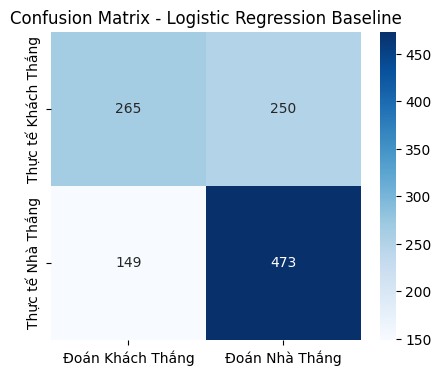



--- Mô hình: XGBoost Classifier ---
Accuracy : 0.6491 (Độ chính xác tổng thể)
ROC-AUC  : 0.7068 (Khả năng phân tách Thắng/Thua)
F1-Score : 0.7060

Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.64      0.50      0.56       515
Home Win (1)       0.65      0.77      0.71       622

    accuracy                           0.65      1137
   macro avg       0.65      0.64      0.64      1137
weighted avg       0.65      0.65      0.64      1137



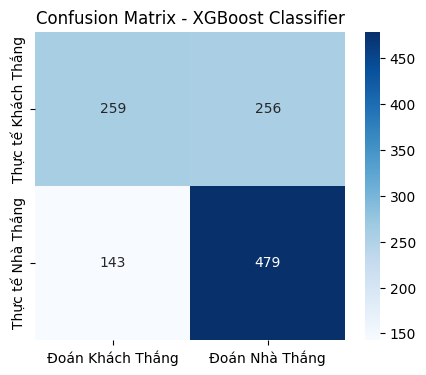


4. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)


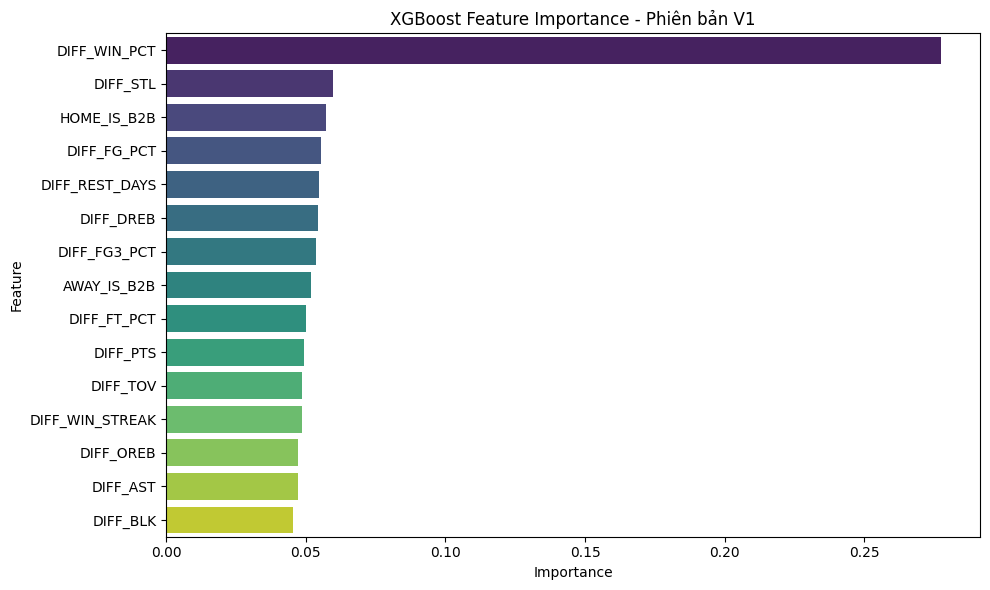

In [19]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Machine Learning
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# 1. Đọc file cấu hình và dữ liệu
print("1. ĐANG LOAD DỮ LIỆU...")
try:
    with open('/kaggle/working/output/feature_config_v1.json', 'r', encoding='utf-8') as f:
        config = json.load(f)
    FEATURES = config['feature_set']
    LABEL = config['label']
except FileNotFoundError:
    print("⚠️ Không tìm thấy file JSON. Đang dùng danh sách thủ công...")
    FEATURES = ['DIFF_PTS', 'DIFF_FG_PCT', 'DIFF_FG3_PCT', 'DIFF_FT_PCT', 'DIFF_OREB', 
                'DIFF_DREB', 'DIFF_AST', 'DIFF_STL', 'DIFF_BLK', 'DIFF_TOV', 
                'DIFF_WIN_PCT', 'DIFF_WIN_STREAK', 'DIFF_REST_DAYS', 'HOME_IS_B2B', 'AWAY_IS_B2B']
    LABEL = 'HOME_WIN'

train_df = pd.read_csv('/kaggle/working/output/eval_train_v1.csv')
test_df = pd.read_csv('/kaggle/working/output/eval_test_v1.csv')

X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_test, y_test = test_df[FEATURES], test_df[LABEL]

print(f"✅ X_train shape: {X_train.shape} | y_train phân bố: {y_train.mean():.1%} Home Win")
print(f"✅ X_test shape:  {X_test.shape}  | y_test phân bố:  {y_test.mean():.1%} Home Win\n")

# 2. Huấn luyện mô hình Baseline (Logistic Regression) và XGBoost
print("2. ĐANG HUẤN LUYỆN MÔ HÌNH...")

# Mô hình 1: Logistic Regression (Rất tốt để làm baseline cho bài toán thể thao)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Mô hình 2: XGBoost (Thuật toán Tree-based mạnh nhất)
xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=4,        
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("✅ Huấn luyện xong!\n")

# 3. Đánh giá mô hình trên tập Test (Mùa 2025-26)
print("3. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (OUT-OF-TIME)")
print("="*60)

def evaluate_model(name, model, X, y_true):
    # Dự đoán nhãn (0/1) và xác suất (0.0 -> 1.0)
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    # Tính các metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    print(f"--- Mô hình: {name} ---")
    print(f"Accuracy : {acc:.4f} (Độ chính xác tổng thể)")
    print(f"ROC-AUC  : {auc:.4f} (Khả năng phân tách Thắng/Thua)")
    print(f"F1-Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Away Win (0)', 'Home Win (1)']))
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Đoán Khách Thắng', 'Đoán Nhà Thắng'], 
                yticklabels=['Thực tế Khách Thắng', 'Thực tế Nhà Thắng'])
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    
    return model

# Gọi hàm đánh giá
evaluate_model("Logistic Regression Baseline", lr_model, X_test, y_test)
print("\n")
evaluate_model("XGBoost Classifier", xgb_model, X_test, y_test)

# 4. Phân tích Feature Importance của XGBoost
print("\n4. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (FEATURE IMPORTANCE)")
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('XGBoost Feature Importance - Phiên bản V1')
plt.tight_layout()
plt.show()